In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os 
from dotenv import load_dotenv
from langgraph.prebuilt import create_react_agent
from langgraph_supervisor import create_supervisor
from langgraph.checkpoint.memory import InMemorySaver
from langchain_tavily import TavilySearch
from langchain.prompts import PromptTemplate
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
import base64
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI

In [2]:
load_dotenv()

True

In [3]:
checkpointer = InMemorySaver()
store = InMemorySaver()

In [4]:
llm = ChatGoogleGenerativeAI(model=os.getenv("GOOGLE_MODEL"))
image_llm = ChatGoogleGenerativeAI(model="models/gemini-2.0-flash-preview-image-generation")

In [5]:
# llm =  ChatGroq(api_key="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" , model="llama3-70b-8192")

In [6]:
# llm = ChatOpenAI(model="gpt-4o-mini")

In [7]:
@tool
def tavily_search_tool_func(query: str) -> str:
    """This is web expert use it Ideal for retrieving fresh, factual, or real-time information from the internet"""
    return TavilySearch(max_results=5, topic="general").invoke(query)

web_search_agent = create_react_agent(model=llm, tools=[tavily_search_tool_func], name="web_expert")


In [8]:
@tool
def llm_based_search_func(query: str) -> str:
    """Answer general knowledge queries using LLM."""
    return llm.invoke(query).content

llm_search_agent = create_react_agent(model=llm, tools=[llm_based_search_func], name="llm_expert")


In [9]:
@tool
def image_gen_func(query: str) -> str:

    """Generate an image based on the description."""
    
    enhanced_query = (
        f"Create an image illustrating the following concept:\n{query}\n\n"
        "Only use English for any text in the image, and avoid unnecessary words."
    )
    response = image_llm.invoke(
        [HumanMessage(content=enhanced_query)],
        generation_config=dict(response_modalities=["TEXT", "IMAGE"])
    )

    # Extract image from response
    image_block = next(
        (block for block in response.content if isinstance(block, dict) and "image_url" in block),
        None
    )
    
    if not image_block:
        return "No image was generated."

    image_url = image_block["image_url"].get("url", "")
    if "base64" in image_url:
        base64_data = image_url.split(",")[-1]
        try:
            display(Image(data=base64.b64decode(base64_data), width=300))
        except Exception as e:
            return f"Failed to render image: {e}"
    else:
        return f"Image URL: {image_url}"  # fallback for URL-based image (if any)

    return "Image generated successfully."

image_gen_agent = create_react_agent(model=llm, tools=[image_gen_func], name="image_gen_expert")


In [10]:
workflow = create_supervisor(
    [web_search_agent, llm_search_agent , image_gen_agent],
    model=llm,
    output_mode="full_history"  ,
    prompt="""
You are a supervisor responsible for routing user queries to the correct agent.
Available agents:
1. Web Search Agent — for current events, factual questions, or anything needing web access.
2. LLM Agent — for general knowledge, reasoning, summaries, coding, and explanations.
3. Image Generator Agent — for anything that requires generating or describing images.

Decide based only on the user’s query. Do not ask follow-up questions. Do not mix multiple agents.

After receiving the result from the selected agent, create a final, helpful, and complete answer based on their output. Avoid saying things like “I’m back” or “Here’s what I found”—just give the user what they asked for directly.
"""
)


In [11]:
app = workflow.compile(checkpointer=checkpointer,debug=True )

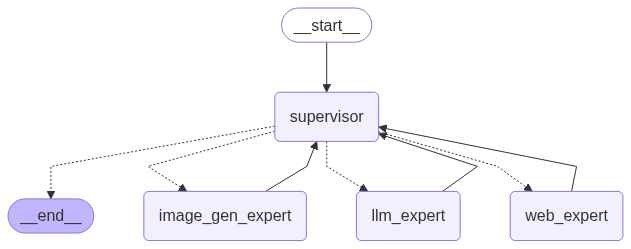

In [12]:
from IPython.display import display , Image
display(Image(app.get_graph().draw_mermaid_png()))

In [13]:
config = {"configurable": {"thread_id": "1"}}

In [14]:
result = app.invoke({
    "messages": [
        {
            "role": "user",
            "content": "current wether update of ahmedabad"
        }
    ]
} , config=config)

[-1:checkpoint] State at the end of step -1:
{'messages': []}
[0:tasks] Starting 1 task for step 0:
- __start__ -> {'messages': [{'content': 'current wether update of ahmedabad',
               'role': 'user'}]}
[0:writes] Finished step 0 with writes to 1 channel:
- messages -> [{'content': 'current wether update of ahmedabad', 'role': 'user'}]
[0:checkpoint] State at the end of step 0:
{'messages': [HumanMessage(content='current wether update of ahmedabad', additional_kwargs={}, response_metadata={}, id='7f8619a0-2cf2-409e-8b3b-9a5dd9f03065')]}
[1:tasks] Starting 1 task for step 1:
- supervisor -> {'is_last_step': False,
 'messages': [HumanMessage(content='current wether update of ahmedabad', additional_kwargs={}, response_metadata={}, id='7f8619a0-2cf2-409e-8b3b-9a5dd9f03065')],
 'remaining_steps': 24}
[1:writes] Finished step 1 with writes to 1 channel:
- messages -> [HumanMessage(content='current wether update of ahmedabad', additional_kwargs={}, response_metadata={}, id='7f8619a0-

In [15]:
print(result)

{'messages': [HumanMessage(content='current wether update of ahmedabad', additional_kwargs={}, response_metadata={}, id='7f8619a0-2cf2-409e-8b3b-9a5dd9f03065'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'transfer_to_web_expert', 'arguments': '{}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, name='supervisor', id='run--9b99d4a4-8578-4a0f-a236-b3343b4b4cb8-0', tool_calls=[{'name': 'transfer_to_web_expert', 'args': {}, 'id': '454ffdee-7c69-446c-93ea-6eb43552672c', 'type': 'tool_call'}], usage_metadata={'input_tokens': 216, 'output_tokens': 7, 'total_tokens': 223, 'input_token_details': {'cache_read': 0}}), ToolMessage(content='Successfully transferred to web_expert', name='transfer_to_web_expert', id='508e529a-e483-42e6-afc9-6cc78265e5eb', tool_call_id='454ffdee-7c69-446c-93ea-6eb43552672c'), AIMessage(content='', additional_kwargs={'function_ca

In [16]:
import pprint
pprint.pprint(result)

{'messages': [HumanMessage(content='current wether update of ahmedabad', additional_kwargs={}, response_metadata={}, id='7f8619a0-2cf2-409e-8b3b-9a5dd9f03065'),
              AIMessage(content='', additional_kwargs={'function_call': {'name': 'transfer_to_web_expert', 'arguments': '{}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, name='supervisor', id='run--9b99d4a4-8578-4a0f-a236-b3343b4b4cb8-0', tool_calls=[{'name': 'transfer_to_web_expert', 'args': {}, 'id': '454ffdee-7c69-446c-93ea-6eb43552672c', 'type': 'tool_call'}], usage_metadata={'input_tokens': 216, 'output_tokens': 7, 'total_tokens': 223, 'input_token_details': {'cache_read': 0}}),
              ToolMessage(content='Successfully transferred to web_expert', name='transfer_to_web_expert', id='508e529a-e483-42e6-afc9-6cc78265e5eb', tool_call_id='454ffdee-7c69-446c-93ea-6eb43552672c'),
              AIMessage(c

In [17]:
print(result["messages"][-1].content)

The current weather in Ahmedabad, Gujarat, India is sunny with a temperature of 39.4°C (102.9°F). It feels like 40.8°C (105.4°F). The wind is from the WNW at 5.4 km/h. Humidity is at 25%.


In [18]:
for chunk in app.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is ai?"
            }
        ]
    } , 
    config=config
):
    print(chunk)
    print("\n")

[4:checkpoint] State at the end of step 4:
{'messages': [HumanMessage(content='current wether update of ahmedabad', additional_kwargs={}, response_metadata={}, id='7f8619a0-2cf2-409e-8b3b-9a5dd9f03065'),
              AIMessage(content='', additional_kwargs={'function_call': {'name': 'transfer_to_web_expert', 'arguments': '{}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, name='supervisor', id='run--9b99d4a4-8578-4a0f-a236-b3343b4b4cb8-0', tool_calls=[{'name': 'transfer_to_web_expert', 'args': {}, 'id': '454ffdee-7c69-446c-93ea-6eb43552672c', 'type': 'tool_call'}], usage_metadata={'input_tokens': 216, 'output_tokens': 7, 'total_tokens': 223, 'input_token_details': {'cache_read': 0}}),
              ToolMessage(content='Successfully transferred to web_expert', name='transfer_to_web_expert', id='508e529a-e483-42e6-afc9-6cc78265e5eb', tool_call_id='454ffdee-7c69-446c-93e

In [19]:
for chunk in app.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "What was last query"
            }
        ]
    } , 
    config=config
):
    print(chunk)
    print("\n")

[9:checkpoint] State at the end of step 9:
{'messages': [HumanMessage(content='current wether update of ahmedabad', additional_kwargs={}, response_metadata={}, id='7f8619a0-2cf2-409e-8b3b-9a5dd9f03065'),
              AIMessage(content='', additional_kwargs={'function_call': {'name': 'transfer_to_web_expert', 'arguments': '{}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, name='supervisor', id='run--9b99d4a4-8578-4a0f-a236-b3343b4b4cb8-0', tool_calls=[{'name': 'transfer_to_web_expert', 'args': {}, 'id': '454ffdee-7c69-446c-93ea-6eb43552672c', 'type': 'tool_call'}], usage_metadata={'input_tokens': 216, 'output_tokens': 7, 'total_tokens': 223, 'input_token_details': {'cache_read': 0}}),
              ToolMessage(content='Successfully transferred to web_expert', name='transfer_to_web_expert', id='508e529a-e483-42e6-afc9-6cc78265e5eb', tool_call_id='454ffdee-7c69-446c-93e